<a href="https://colab.research.google.com/github/shakinul-islam/Python/blob/main/Heart_disease_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**HEART DISEASE PREDICTION MODEL**

Please upload your 'heart.csv' file:


Saving heart.csv to heart (5).csv

Successfully loaded: heart (5).csv

--- Dataset Preview ---
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 

/tmp/ipykernel_6882/3633925605.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


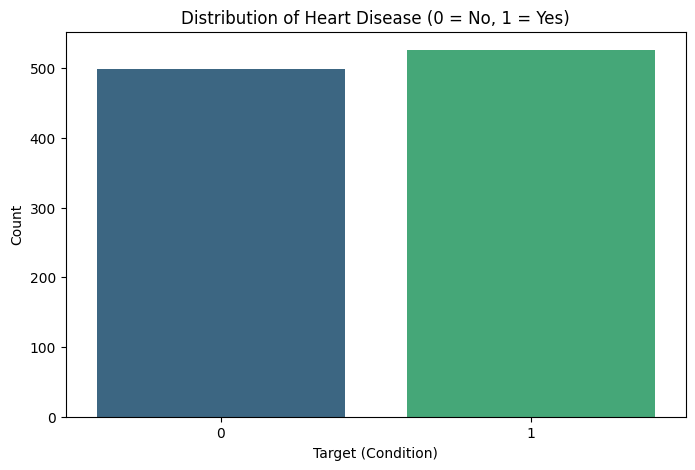


Training Random Forest Classifier...
Training Complete!

             MODEL PERFORMANCE

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205


----------------------------------------
Accuracy Score: 98.54%
F1 Score (Weighted): 0.99
----------------------------------------


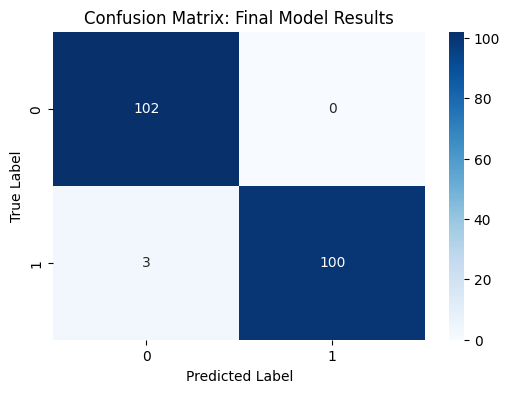

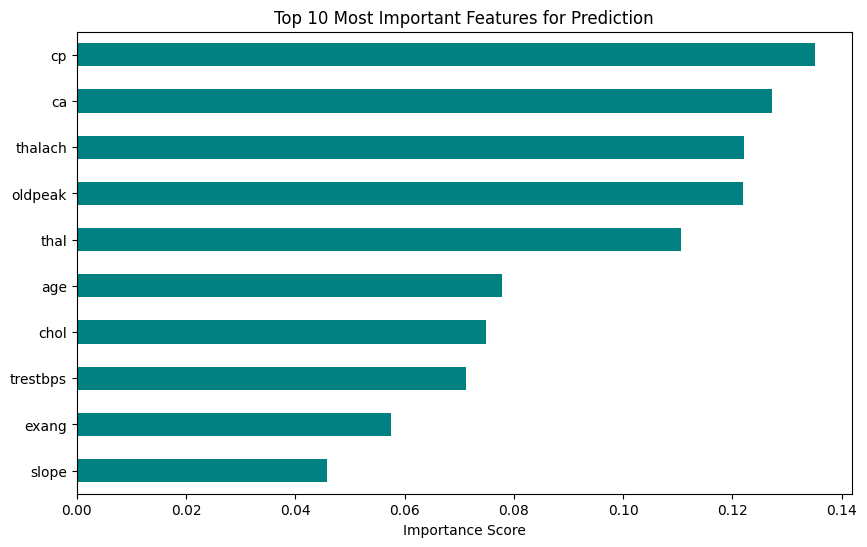


--- New Patient Prediction ---
Prediction Result: Heart Disease Detected
Confidence Level: 99.00%


In [7]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# --- Step 1: Load Dataset ---
print("Please upload your 'heart.csv' file:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# Basic dataset info
print(f"\nSuccessfully loaded: {file_name}")
print("\n--- Dataset Preview ---")
print(df.head())
print("\n--- Dataset Info ---")
print(df.info())
print("\n--- Checking for Missing Values ---")
print(df.isnull().sum())

# --- Step 2: Visualize Class Distribution ---
plt.figure(figsize=(8,5))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Distribution of Heart Disease (0 = No, 1 = Yes)')
plt.xlabel('Target (Condition)')
plt.ylabel('Count')
plt.show()

# --- Step 3: Data Preprocessing ---
X = df.drop('target', axis=1)
y = df['target']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --- Step 4: Model Training ---
print("\nTraining Random Forest Classifier...")
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print("Training Complete!")

# --- Step 5: Model Evaluation ---
y_pred = model.predict(X_test)

print("\n" + "="*40)
print("             MODEL PERFORMANCE")
print("="*40)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\n" + "-"*40)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Accuracy Score: {accuracy*100:.2f}%")
print(f"F1 Score (Weighted): {f1:.2f}")
print("-"*40)

# --- Step 6: Confusion Matrix Visualization ---
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Final Model Results')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- Step 7: Feature Importance Visualization ---
plt.figure(figsize=(10,6))
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Most Important Features for Prediction')
plt.xlabel('Importance Score')
plt.show()

# --- Step 8: Prediction Function for New Patient ---
def predict_new_patient(input_data=None):
    """
    Predict heart disease for a new patient.
    input_data: 1D array or list with same order as X columns.
    If None, uses first row of X_test as demo.
    """
    print("\n--- New Patient Prediction ---")
    try:
        if input_data is None:
            test_input = X_test[0].reshape(1, -1)
        else:
            test_input = scaler.transform([input_data])

        res = model.predict(test_input)
        prob = model.predict_proba(test_input)
        status = "Heart Disease Detected" if res[0]==1 else "No Heart Disease Detected"
        print(f"Prediction Result: {status}")
        print(f"Confidence Level: {max(prob[0])*100:.2f}%")
    except Exception as e:
        print(f"Error in prediction: {e}")

# Example Prediction Call
predict_new_patient()